In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv
/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/data_description.txt
/kaggle/input/competitions/home-data-for-ml-course/test.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv
/kaggle/input/competitions/home-data-for-ml-course/test.csv


In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv")
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
import pandas as pd
import numpy as np

train_data = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/test.csv")

print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [4]:
print(train_data.head())
print("\n====================\n")
print(test_data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [5]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x : (x - x.mean()) / (x.std())
)
all_features[numeric_features] = all_features[numeric_features].fillna(0)

In [6]:
all_features = pd.get_dummies(all_features, dummy_na = True)
all_features.shape

(2919, 330)

In [7]:
import torch

all_features = all_features*1
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

In [8]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net

def log_rmsle(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf')) 
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

def train(net, train_features, train_labels, test_features, test_labels, 
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_dataset = TensorDataset(train_features, train_labels)
    train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()

        train_ls.append(log_rmsle(net, train_features, train_labels))
            
        if test_labels is not None:
            test_ls.append(log_rmsle(net, test_features, test_labels))
    
    return train_ls, test_ls

In [9]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid
    

In [10]:
import matplotlib.pyplot as plt

def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    
    for i in range(k):
        # 1. 获取第 i 折的训练集和验证集
        data = get_k_fold_data(k, i, X_train, y_train)
        
        # 2. 重新初始化模型（每一折都用全新的网络）
        net = get_net()
        
        # 3. 训练模型，得到每一轮的 rmse 列表
        # 注意这里 *data 的解包顺序：X_train, y_train, X_valid, y_valid
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)
        
        # 4. 累加最后一轮（收敛后）的误差，用于计算平均值
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        
        # 5. 仅针对第 1 折（i=0）绘制学习曲线（替代 d2l.plot）
        if i == 0:
            epochs = list(range(1, num_epochs + 1))
            plt.figure(figsize=(8, 5))          # 设置画布大小
            plt.plot(epochs, train_ls, label='train', marker='o')
            plt.plot(epochs, valid_ls, label='valid', marker='s')
            plt.xlabel('epoch')
            plt.ylabel('rmse')
            plt.xlim(1, num_epochs)
            plt.yscale('log')                   # 对数坐标，便于观察收敛
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.title('Learning Curve (Fold 1)')
            plt.show()
        
        # 6. 打印当前折的最终误差
        print(f'fold {i + 1}, train log rmse {float(train_ls[-1]):f}, '
              f'valid log rmse {float(valid_ls[-1]):f}')
    
    # 7. 返回 k 折的平均误差
    return train_l_sum / k, valid_l_sum / k

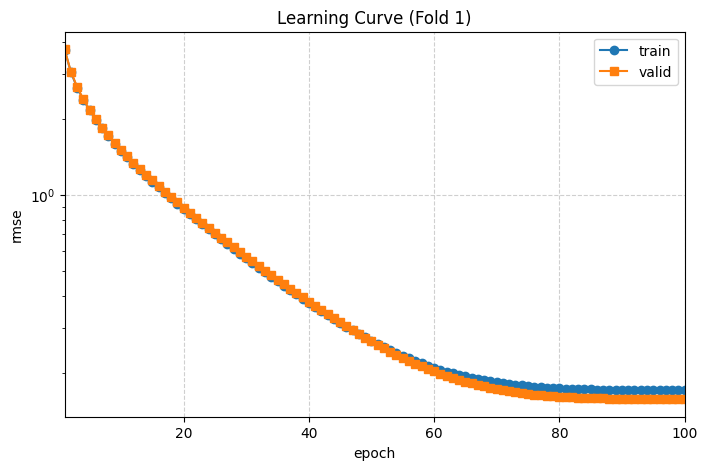

fold 1, train log rmse 0.170255, valid log rmse 0.157077
fold 2, train log rmse 0.161764, valid log rmse 0.188954
fold 3, train log rmse 0.164007, valid log rmse 0.168284
fold 4, train log rmse 0.167843, valid log rmse 0.154233
fold 5, train log rmse 0.163391, valid log rmse 0.183067
5-折验证: 平均训练log rmse: 0.165452, 平均验证log rmse: 0.170323


In [11]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

In [12]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    
    # ----------------- 替代 d2l.plot -----------------
    epochs = np.arange(1, num_epochs + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_ls, label='train', marker='o')
    plt.xlabel('epoch')
    plt.ylabel('log rmse')
    plt.xlim(1, num_epochs)
    plt.yscale('log')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.title('Training Log RMSE')
    plt.show()
    # ------------------------------------------------
    
    print(f'train log rmse {float(train_ls[-1]):f}')
    
    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)


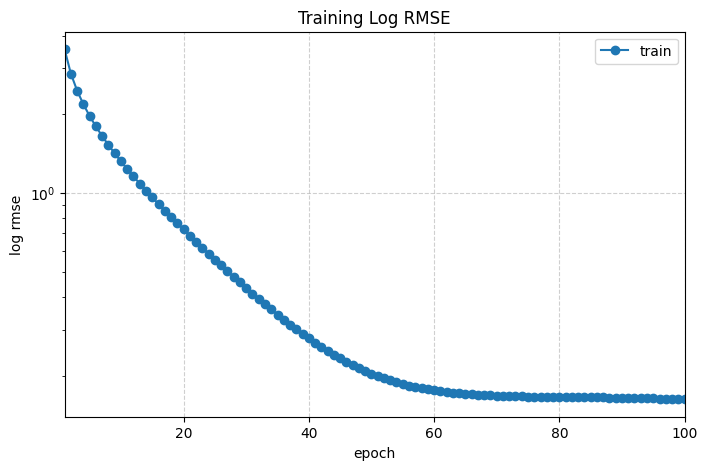

train log rmse 0.162549


In [13]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)